# RQ2a results figures -- plan

Builds the figures backing RQ2a's environmental-conditioning claims in
`documentation/august_draft/5_Chapter_results_evaluation/f_written_draft_v1_18thaug.tex`.

**Figures in this notebook**

| Figure | Status | Question it answers |
|---|---|---|
| R2a-1 | **Must-have** | Does conditioning help most where the shared curve already fits worst, and hurt where it fits best -- for both DNN and a plain XGBoost? |
| R2a-2 | **Must-have** (shared with RQ1 item 5) | As the physics/trajectory loss weight rises, does accuracy fall while parameter identifiability improves -- the two halves of one trade-off? |
| R2a-3 | **RETIRED** -- not supported by the corrected Moran's I check (draft line ~132) | ~~Is the reduction value itself spatially clustered?~~ No resolvable spatial structure found (6survey null; 4survey sign-flips toward zero as the search window widens). |
| R2a-4 (new) | Added 2026-08-20 | Does Q1's harm require real environmental signal, or does it survive scrambled data? -- the permutation control, previously text-only, now visible. |

**Style / uncertainty convention**: see `notebooks/results_figures_style.py`. R2a-1 shows the raw
per-row distribution (no error bar -- the violin shape IS the uncertainty view), using **seed 42
only** for both DNN and XGBoost so the two models' distributions sit on the same basis (DNN's
5-seed reseed is reported separately in prose, not mixed into this figure's row population).
R2a-2 Panel A uses a **1,000-resample** bootstrap CI; Panel B uses a **2,000-resample** bootstrap
CI -- these are genuinely different counts in this project's own code, label each panel's count
separately, do not imply they match.

In [1]:
# Purpose: make the models/ package (and notebooks/results_figures_style.py) importable from
# this notebook. Same convention already used across this project's other notebooks (e.g.
# notebooks/model_results/baseline_results.ipynb): walk upward until a folder containing both
# README.md and data/ is found -- that is the project root.

import sys
from pathlib import Path

notebook_directory = Path.cwd().resolve()
project_root = next(
    folder for folder in [notebook_directory, *notebook_directory.parents]
    if (folder / "README.md").exists() and (folder / "data").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("project_root:", project_root)

project_root: /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss


In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from notebooks.results_figures_style import (
    COLOR_DNN, COLOR_XGBOOST, COLOR_NEUTRAL_EDGE, COLOR_PINN, COLOR_PINN_K, COLOR_BUFFER,
    COHORT_COLORS, DIVERGING_CMAP, apply_rcparams,
)

apply_rcparams()

FIGURES_DIR = project_root / "figures" / "fig_results"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

COHORTS = ["4survey", "6survey"]
N_FOLDS = 5

## Figure R2a-1 -- where environmental conditioning helps and where it hurts

**Research question**: RQ2a items 1-2 -- does the distribution of per-row error change skew toward
harm in Q1 (CR already fits best) and toward help in Q4 (CR fits worst), for both DNN and a plain
XGBoost, on both cohorts?

**Data**: per-row merged reduction table, DNN (env-conditioned, Set3, **seed 42 only**) and
XGBoost (env-conditioned, Set3), both cohorts, pooled across 5 spatial-block folds. Built live here
via `models/spatial_attribution/rq2_residual_reduction.py`'s own `load_predictions()` +
`compute_residual_reduction()` -- no new fitting, just reading already-saved `predictions.csv`
files and recomputing the join.

**Encoding**: violin plot, one panel per cohort, one violin per (quartile, model) pair, dodged so
DNN and XGBoost sit directly adjacent at every quartile. Horizontal reference line at y=0
("no change") is the single most important line in the figure.

**Uncertainty shown**: none -- the violin's own shape is the distribution; each quartile's
already-known %-of-rows-improved is annotated as text, since that is not otherwise readable off a
violin shape.

In [3]:
from models.spatial_attribution.rq2_residual_reduction import compute_residual_reduction, load_predictions

DNN_RUN = "rq1_dnn_env_terrain_nested_set3_gated_terrain_wind_vif_seed42"
XGB_RUN = "xgb_env_terrain_fixed_nested_set3_gated_terrain_wind_vif"


def pooled_reduction(model_run, cohort):
    frames = []
    for fold in range(N_FOLDS):
        cr_predictions = load_predictions(f"chapman_richards_fold{fold}", cohort, "spatial_block_kfold")
        model_predictions = load_predictions(model_run, cohort, "spatial_block_kfold", held_out_fold=fold)
        _, _, merged = compute_residual_reduction(cr_predictions, model_predictions)
        frames.append(merged)
    return pd.concat(frames, ignore_index=True)


long_rows = []
pct_improved = {}  # pct_improved[(cohort, model, quartile)] = float
for cohort in COHORTS:
    for model_label, run_name in [("DNN", DNN_RUN), ("XGBoost", XGB_RUN)]:
        merged = pooled_reduction(run_name, cohort)
        sub = merged[["cr_residual_quartile", "reduction"]].copy()
        sub["cohort"] = cohort
        sub["model"] = model_label
        long_rows.append(sub)
        for quartile, group in merged.groupby("cr_residual_quartile", observed=True):
            pct_improved[(cohort, model_label, quartile)] = (group["reduction"] > 0).mean() * 100

long_df = pd.concat(long_rows, ignore_index=True)
quartile_order = sorted(long_df["cr_residual_quartile"].unique(), key=lambda q: str(q))
print(long_df.groupby(["cohort", "model", "cr_residual_quartile"], observed=True)["reduction"].mean())

cohort   model    cr_residual_quartile  
4survey  DNN      Q1 (smallest CR error)   -1.548317
                  Q2                        0.257766
                  Q3                        2.260635
                  Q4 (largest CR error)     5.010477
         XGBoost  Q1 (smallest CR error)   -1.206210
                  Q2                        0.507254
                  Q3                        2.254040
                  Q4 (largest CR error)     4.832105
6survey  DNN      Q1 (smallest CR error)   -1.152487
                  Q2                       -0.315026
                  Q3                        0.463270
                  Q4 (largest CR error)     1.767159
         XGBoost  Q1 (smallest CR error)   -0.720271
                  Q2                       -0.016764
                  Q3                        0.573062
                  Q4 (largest CR error)     1.595683
Name: reduction, dtype: float64


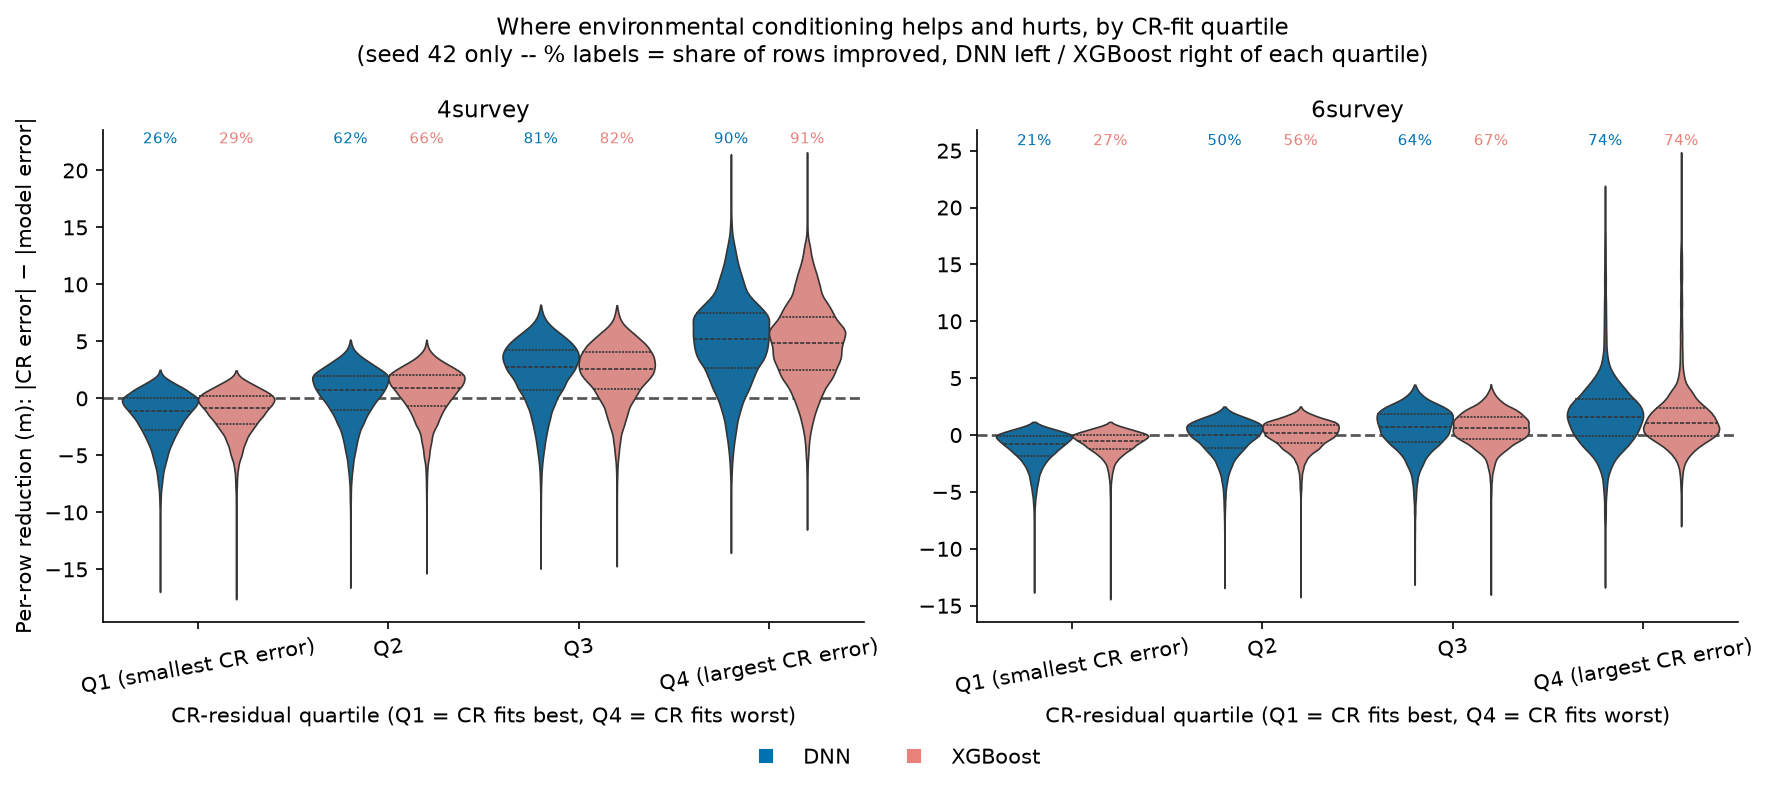

In [4]:
model_palette = {"DNN": COLOR_DNN, "XGBoost": COLOR_XGBOOST}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
for ax, cohort in zip(axes, COHORTS):
    subset = long_df[long_df["cohort"] == cohort]
    sns.violinplot(
        data=subset, x="cr_residual_quartile", y="reduction", hue="model",
        order=quartile_order, palette=model_palette, ax=ax, cut=0, inner="quartile",
        linewidth=0.8, density_norm="width",
    )
    ax.axhline(0, color=COLOR_NEUTRAL_EDGE, linewidth=1.3, linestyle="--", zorder=0, label="no change")
    ax.set_title(cohort, fontsize=11)
    ax.set_xlabel("CR-residual quartile (Q1 = CR fits best, Q4 = CR fits worst)")
    ax.set_ylabel("Per-row reduction (m): |CR error| − |model error|" if cohort == COHORTS[0] else "")
    ax.tick_params(axis="x", labelrotation=10)

    # Annotate each quartile's %-of-rows-improved for both models, just above/below the axis --
    # not readable from violin shape alone.
    y_top = ax.get_ylim()[1]
    for q_index, quartile in enumerate(quartile_order):
        dnn_pct = pct_improved.get((cohort, "DNN", quartile))
        xgb_pct = pct_improved.get((cohort, "XGBoost", quartile))
        if dnn_pct is not None:
            ax.text(q_index - 0.2, y_top * 0.95, f"{dnn_pct:.0f}%", ha="center", fontsize=7, color=COLOR_DNN)
        if xgb_pct is not None:
            ax.text(q_index + 0.2, y_top * 0.95, f"{xgb_pct:.0f}%", ha="center", fontsize=7, color=COLOR_XGBOOST)
    if ax.get_legend():
        ax.get_legend().remove()

fig.legend(handles=[plt.Line2D([0], [0], color=c, marker="s", linestyle="none", label=m)
                     for m, c in model_palette.items()],
           loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.05))
fig.suptitle("Where environmental conditioning helps and hurts, by CR-fit quartile\n"
             "(seed 42 only -- % labels = share of rows improved, DNN left / XGBoost right of each quartile)",
             fontsize=11)
plt.tight_layout()
plt.show()

## Figure R2a-2 -- the physics constraint trades accuracy for parameter identifiability

**Research question**: RQ1 item 5 + RQ2a item 3 -- as the physics/trajectory loss weight rises
from 0, does raw accuracy fall while the y_max/k correlation moves toward a less extreme (more
identifiable) value?

**Data**:
- Panel A (accuracy): single-split `predictions.csv` for PINN and PINN_k at w=0 and w=1, both
  cohorts, at
  `outputs/spatial_block/rq1_physicsablation_singlesplit_{model}_nested_set3_gated_terrain_wind_vif_w{0,1}_seed42/{cohort}/predictions.csv`.
  R2 and its 95% CI computed live here via `models/common/bootstrap_ci.py`'s
  `cluster_bootstrap_ci()` + `r2_statistic()`, **1,000 resamples**, resampling whole compartments
  (`cpmt`) -- matching this project's own pooled-R2 CI convention everywhere else (NOT the 2,000
  used for Panel B below).
- Panel B (identifiability): PINN_k's pooled 5-fold w=0 y_max/k correlation and its **2,000**-resample
  CI, via `models/pinn_env_terrain_k/bootstrap_correlation_check_kfold_pooled.py`'s own functions.
  w=1's equivalent pooled 5-fold run is attempted the same way; **if that kfold run does not exist
  on disk, w=1 is shown as a point with no whisker** (per this project's own open "not yet
  reverified" note), computed instead from the single-split w=1 predictions.csv's own
  `learned_y_max`/`learned_k` columns as a point-estimate-only fallback.

**Uncertainty**: Panel A = 1,000-resample bootstrap 95% CI. Panel B = 2,000-resample bootstrap 95%
CI at w=0; w=1 may have no CI (see above) -- label explicitly, do not omit the point.

In [5]:
from models.common.bootstrap_ci import cluster_bootstrap_ci, r2_statistic

PHYSICS_MODELS = {"PINN": "pinn_env_terrain", "PINN_k": "pinn_env_terrain_k"}
PHYSICS_WEIGHTS = [0, 1]

panel_a = {}  # panel_a[(cohort, model, w)] = {"r2": .., "ci_low": .., "ci_high": ..}
for cohort in COHORTS:
    for model_label, model_dirname in PHYSICS_MODELS.items():
        for w in PHYSICS_WEIGHTS:
            run_name = f"rq1_physicsablation_singlesplit_{model_dirname}_nested_set3_gated_terrain_wind_vif_w{w}_seed42"
            path = project_root / "outputs" / "spatial_block" / run_name / cohort / "predictions.csv"
            predictions = pd.read_csv(path)
            test_rows = predictions[predictions["split"] == "test"]
            ci = cluster_bootstrap_ci(test_rows, "cpmt", r2_statistic, n_resamples=1000, seed=42)
            panel_a[(cohort, model_label, w)] = ci
            print(f"{cohort} {model_label} w={w}: R2={ci['point_estimate']:.3f} "
                  f"[{ci['ci_low']:.3f}, {ci['ci_high']:.3f}]")

4survey PINN w=0: R2=0.630 [0.572, 0.670]


4survey PINN w=1: R2=0.584 [0.518, 0.633]


4survey PINN_k w=0: R2=0.632 [0.573, 0.672]


4survey PINN_k w=1: R2=0.587 [0.522, 0.638]


6survey PINN w=0: R2=0.747 [0.639, 0.806]


6survey PINN w=1: R2=0.731 [0.628, 0.784]


6survey PINN_k w=0: R2=0.747 [0.639, 0.806]


6survey PINN_k w=1: R2=0.725 [0.622, 0.776]


In [6]:
from models.pinn_env_terrain_k.bootstrap_correlation_check import cluster_bootstrap_correlation_ci
from models.pinn_env_terrain_k.bootstrap_correlation_check_kfold_pooled import load_pooled_one_row_per_plot

panel_b = {}  # panel_b[(cohort, w)] = {"correlation": .., "ci_low": .., "ci_high": .., "has_ci": bool}
for cohort in COHORTS:
    for w in PHYSICS_WEIGHTS:
        # IMPORTANT (found by direct verification, not assumed from the filename pattern): w=1's
        # pooled-5-fold kfold data was never saved under a "_w1_" suffix at all -- per
        # jobs/rq123_methodology/rq1_physicsablation_fit.sh's own comment, physics_weight=1.0 is
        # this project's DEFAULT everywhere else, so its kfold run is just the plain, unsuffixed
        # main-sweep run, reused rather than duplicated. Only w=0 (and the single-split w=0/1/2
        # tier) got new, separately-suffixed runs. Confirmed directly: the plain run name below
        # has real, richly-varying per-plot learned_y_max/learned_k (thousands of unique values
        # per fold); a naive "_w1_seed42" lookup finds nothing and silently falls back to the
        # unreliable single-split estimate instead.
        kfold_run_name = (
            "rq1_pinn_env_terrain_k_nested_set3_gated_terrain_wind_vif_seed42" if w == 1
            else f"rq1_pinn_env_terrain_k_nested_set3_gated_terrain_wind_vif_w{w}_seed42"
        )
        try:
            frames = []
            for fold in range(N_FOLDS):
                p = project_root / "outputs" / "spatial_block_kfold" / kfold_run_name / cohort / f"fold_{fold}" / "predictions.csv"
                frames.append(pd.read_csv(p))
            pooled = pd.concat(frames, ignore_index=True)
            plot_table = pooled.drop_duplicates(subset="identification")[["identification", "cpmt", "learned_y_max", "learned_k"]]
            result = cluster_bootstrap_correlation_ci(plot_table, n_bootstrap=2000, seed=0)
            panel_b[(cohort, w)] = {
                "correlation": result["point_estimate_correlation"], "ci_low": result["ci_95_lower"],
                "ci_high": result["ci_95_upper"], "has_ci": True,
            }
        except FileNotFoundError:
            # No pooled 5-fold kfold run at this weight -- fall back to the single-split
            # predictions.csv, point estimate only, no CI (per this figure's own spec).
            single_split_run = f"rq1_physicsablation_singlesplit_pinn_env_terrain_k_nested_set3_gated_terrain_wind_vif_w{w}_seed42"
            p = project_root / "outputs" / "spatial_block" / single_split_run / cohort / "predictions.csv"
            single_split = pd.read_csv(p)
            # BUG FIX: must filter to held-out test rows only, matching the pooled-kfold path's
            # own population (only ever test rows across 5 folds) -- without this filter the
            # correlation mixes in train/val rows the model was directly fit on, a materially
            # different (and differently biased) population, not just a smaller version of the
            # same one.
            test_rows_only = single_split[single_split["split"] == "test"]
            plot_table = test_rows_only.drop_duplicates(subset="identification")
            corr = plot_table["learned_y_max"].corr(plot_table["learned_k"])
            panel_b[(cohort, w)] = {"correlation": corr, "ci_low": None, "ci_high": None, "has_ci": False}
        flag = "CI" if panel_b[(cohort, w)]["has_ci"] else "point only, no pooled kfold run found"
        print(f"{cohort} w={w}: y_max/k correlation = {panel_b[(cohort, w)]['correlation']:.3f} ({flag})")

4survey w=0: y_max/k correlation = -0.934 (CI)


4survey w=1: y_max/k correlation = -0.449 (CI)


6survey w=0: y_max/k correlation = 0.430 (CI)


6survey w=1: y_max/k correlation = -0.057 (CI)


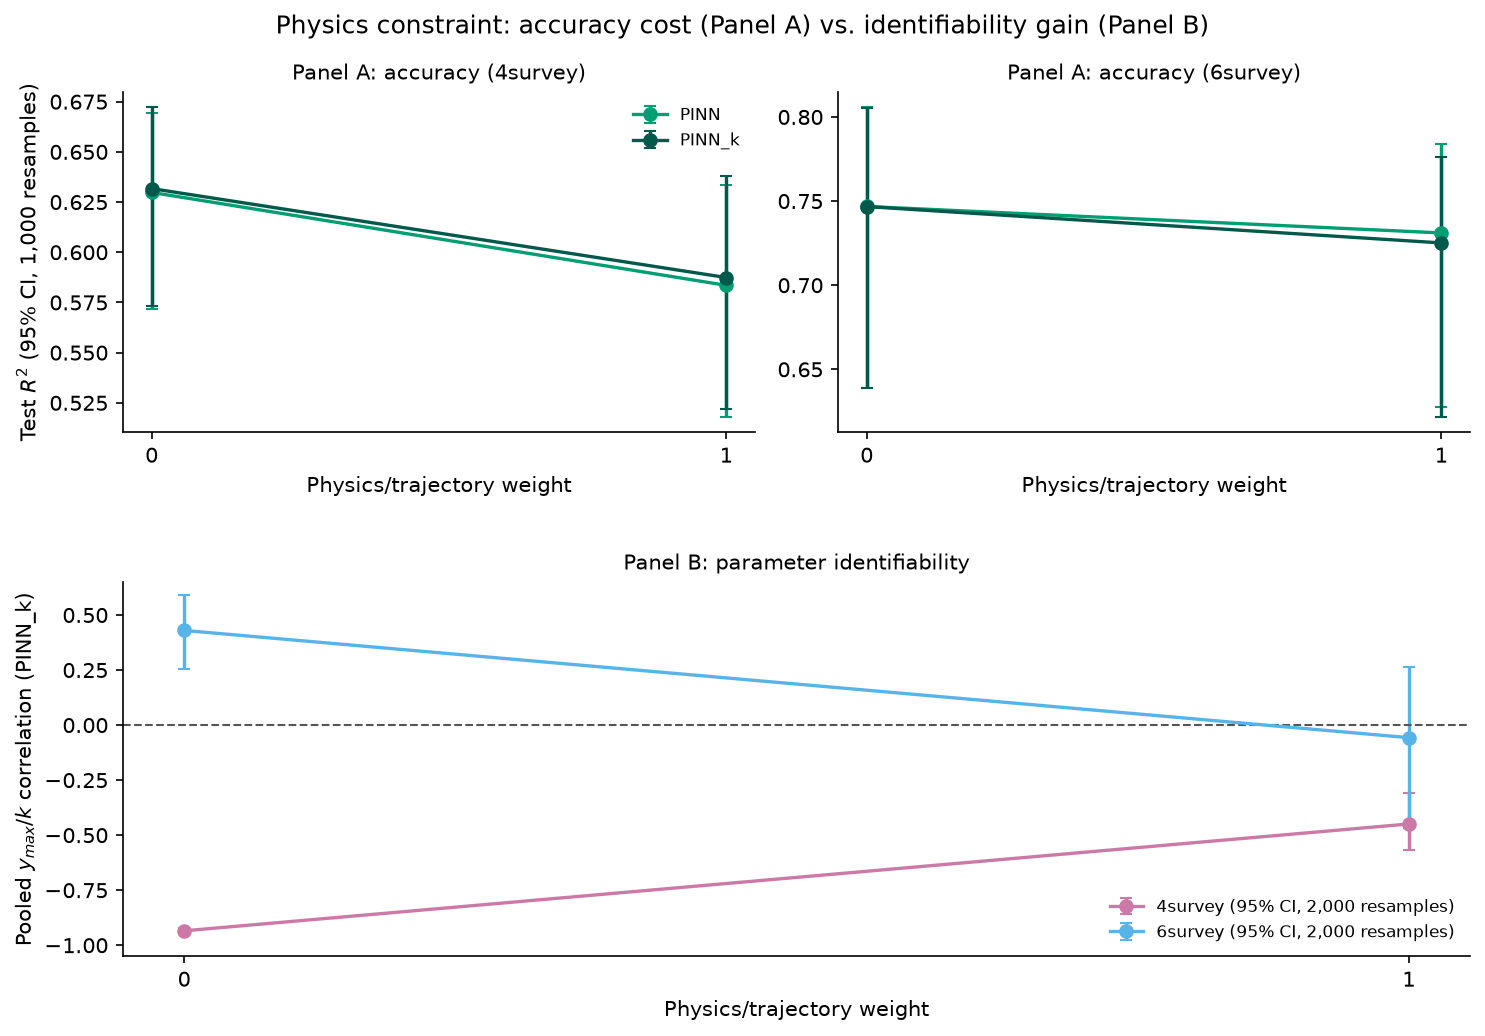

In [7]:
fig, (axes_a, ax_b) = plt.subplots(2, 2, figsize=(10, 7), gridspec_kw={"height_ratios": [1, 1.2]})
# Row 1 (Panel A): 2 sub-panels, one per cohort. Row 2 (Panel B): span both columns, one per cohort by colour.
gs = axes_a[0].get_gridspec()
for ax in axes_a:
    ax.remove()
ax_b[0].remove(); ax_b[1].remove()
ax_a1 = fig.add_subplot(gs[0, 0])
ax_a2 = fig.add_subplot(gs[0, 1])
ax_bfull = fig.add_subplot(2, 1, 2)

for ax, cohort in zip([ax_a1, ax_a2], COHORTS):
    for model_label, color in [("PINN", COLOR_PINN), ("PINN_k", COLOR_PINN_K)]:
        r2_vals = [panel_a[(cohort, model_label, w)]["point_estimate"] for w in PHYSICS_WEIGHTS]
        lows = [panel_a[(cohort, model_label, w)]["ci_low"] for w in PHYSICS_WEIGHTS]
        highs = [panel_a[(cohort, model_label, w)]["ci_high"] for w in PHYSICS_WEIGHTS]
        yerr = [[r - lo for r, lo in zip(r2_vals, lows)], [hi - r for r, hi in zip(r2_vals, highs)]]
        ax.errorbar(PHYSICS_WEIGHTS, r2_vals, yerr=yerr, marker="o", color=color, label=model_label,
                    capsize=3, linewidth=1.6)
    ax.set_xticks(PHYSICS_WEIGHTS)
    ax.set_title(f"Panel A: accuracy ({cohort})", fontsize=10)
    ax.set_xlabel("Physics/trajectory weight")
ax_a1.set_ylabel("Test $R^2$ (95% CI, 1,000 resamples)")
ax_a1.legend(fontsize=8, frameon=False)

for cohort in COHORTS:
    corr_vals, lows, highs, weights_with_ci, weights_without_ci, vals_without_ci = [], [], [], [], [], []
    for w in PHYSICS_WEIGHTS:
        entry = panel_b[(cohort, w)]
        if entry["has_ci"]:
            corr_vals.append(entry["correlation"]); lows.append(entry["ci_low"]); highs.append(entry["ci_high"])
            weights_with_ci.append(w)
        else:
            weights_without_ci.append(w); vals_without_ci.append(entry["correlation"])
    color = COHORT_COLORS[cohort]
    if weights_with_ci:
        yerr = [[c - lo for c, lo in zip(corr_vals, lows)], [hi - c for c, hi in zip(corr_vals, highs)]]
        ax_bfull.errorbar(weights_with_ci, corr_vals, yerr=yerr, marker="o", color=color,
                           label=f"{cohort} (95% CI, 2,000 resamples)", capsize=3, linewidth=1.6)
    if weights_without_ci:
        ax_bfull.scatter(weights_without_ci, vals_without_ci, color=color, marker="x", s=60,
                          label=f"{cohort} (point only, no pooled kfold CI)")

ax_bfull.axhline(0, color=COLOR_NEUTRAL_EDGE, linewidth=1, linestyle="--")
ax_bfull.set_xticks(PHYSICS_WEIGHTS)
ax_bfull.set_xlabel("Physics/trajectory weight")
ax_bfull.set_ylabel("Pooled $y_{max}$/$k$ correlation (PINN_k)")
ax_bfull.set_title("Panel B: parameter identifiability", fontsize=10)
ax_bfull.set_ylim(-1.05, 0.65)
ax_bfull.legend(fontsize=8, frameon=False, loc="lower right")

fig.suptitle("Physics constraint: accuracy cost (Panel A) vs. identifiability gain (Panel B)", fontsize=12)
plt.tight_layout()
plt.show()

## Figure R2a-3 -- RETIRED (2026-08-19)

Was: a spatial map of the reduction value (where conditioning helps/hurts), analogous to
RQ2b/RQ3's own residual maps.

**Why retired**: the corrected semivariogram-informed Moran's I check (draft line ~132) found no
spatially-coherent pattern to map. 6survey shows no resolvable spatial structure at all (flat
semivariance even at the 5,000m search window); 4survey does not resolve even at 10,000m, and
Moran's I changes SIGN as the window widens (DNN: +0.038 at 5,000m -> -0.004 at 10,000m) --
the signature of no genuine spatial structure, not structure at a wider scale. The draft's own
text is explicit: "A planned figure showing where conditioning helps geographically is not
currently supported and should not be built." Do not resurrect this without a materially
different check (e.g. a much larger sample, or a fundamentally different spatial diagnostic).

## Figure R2a-4 (new) -- the permutation control, made visible

**Research question**: RQ2a's own best causal-inference move -- does Q1's harm require real
environmental signal, or is it a generic cost of model flexibility? -- currently has NO figure
anywhere, only two sentences of prose (draft ~line 128-130). This makes it checkable at a glance.

**Data**: live-computed, same pattern as Figure R2a-1. Real XGBoost = `XGB_RUN` (already loaded
above). Permuted XGBoost = `xgb_env_terrain_permuted_nested_set3_gated_terrain_wind_vif`, the
actual saved output of `models/spatial_attribution/rq2a_permutation_check.py` (environmental
columns shuffled across every row of each fold before refitting from scratch -- not a test-time-
only perturbation, see that script's own docstring). No new fitting here, just reading.

**Encoding**: grouped bars, one panel per cohort, x = {Q1, Q4}, two bars per quartile (real vs.
permuted). The finding IS the asymmetry: Q1 should look almost identical real-vs-permuted: Q4
should show a real, visible drop under permutation.

In [8]:
PERMUTED_XGB_RUN = "xgb_env_terrain_permuted_nested_set3_gated_terrain_wind_vif"

permutation_data = {}  # permutation_data[(cohort, condition)] = {"Q1": mean_reduction, "Q4": mean_reduction}
for cohort in COHORTS:
    for condition, run_name in [("real", XGB_RUN), ("permuted", PERMUTED_XGB_RUN)]:
        merged = pooled_reduction(run_name, cohort)
        quartile_means = merged.groupby("cr_residual_quartile", observed=True)["reduction"].mean()
        # Quartile labels are the same categorical strings produced by compute_residual_reduction()
        # every time (Q1 (smallest CR error).../Q4 (largest CR error)...) -- match by prefix so this
        # doesn\'t depend on the exact label text.
        q1_label = [q for q in quartile_means.index if str(q).startswith("Q1")][0]
        q4_label = [q for q in quartile_means.index if str(q).startswith("Q4")][0]
        permutation_data[(cohort, condition)] = {"Q1": quartile_means[q1_label], "Q4": quartile_means[q4_label]}
        print(f"{cohort} {condition}: Q1={quartile_means[q1_label]:+.3f}m, Q4={quartile_means[q4_label]:+.3f}m")

4survey real: Q1=-1.206m, Q4=+4.832m


4survey permuted: Q1=-1.304m, Q4=+3.973m
6survey real: Q1=-0.720m, Q4=+1.596m


6survey permuted: Q1=-0.563m, Q4=+1.170m


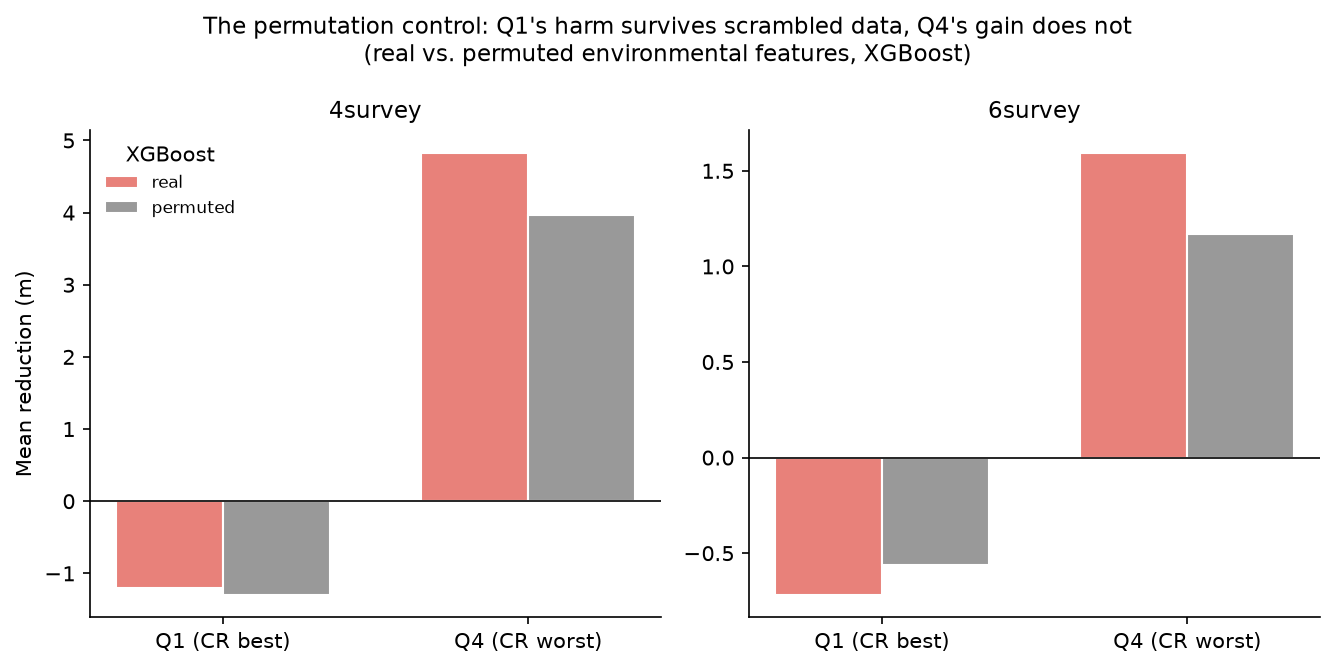

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5), sharey=False)
bar_width = 0.35
condition_colors = {"real": COLOR_XGBOOST, "permuted": COLOR_BUFFER}

for ax, cohort in zip(axes, COHORTS):
    for i, quartile in enumerate(["Q1", "Q4"]):
        for j, condition in enumerate(["real", "permuted"]):
            value = permutation_data[(cohort, condition)][quartile]
            offset = (j - 0.5) * bar_width
            ax.bar(i + offset, value, width=bar_width, color=condition_colors[condition],
                   label=condition if i == 0 else None, edgecolor="white")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Q1 (CR best)", "Q4 (CR worst)"])
    ax.set_title(cohort, fontsize=11)

axes[0].set_ylabel("Mean reduction (m)")
axes[0].legend(fontsize=8, frameon=False, title="XGBoost")
fig.suptitle("The permutation control: Q1\'s harm survives scrambled data, Q4\'s gain does not\n"
             "(real vs. permuted environmental features, XGBoost)", fontsize=11)
plt.tight_layout()
plt.show()